# EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_heart = pd.read_csv('heart.csv')
df_heart = df_heart.drop_duplicates()
df_heart.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


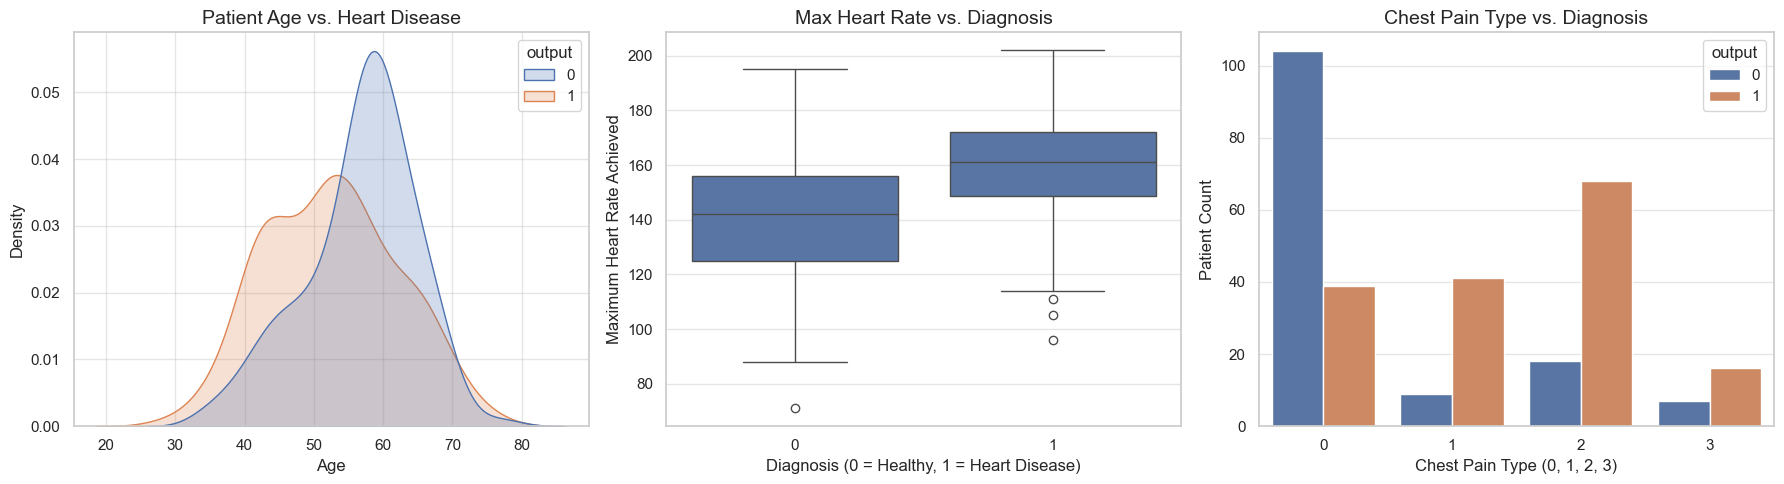

In [6]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
# common_norm=False ensures we can clearly see the shape of both groups independently
sns.kdeplot(data=df_heart, x='age', hue='output', fill=True, common_norm=False)
plt.title('Patient Age vs. Heart Disease', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Density')

# Plot 2: Max Heart Rate vs Heart Disease
plt.subplot(1, 3, 2)
sns.boxplot(data=df_heart, x='output', y='thalachh')
plt.title('Max Heart Rate vs. Diagnosis', fontsize=14)
plt.xlabel('Diagnosis (0 = Healthy, 1 = Heart Disease)')
plt.ylabel('Maximum Heart Rate Achieved')

# Plot 3: Chest Pain Type vs Heart Disease
plt.subplot(1, 3, 3)
sns.countplot(data=df_heart, x='cp', hue='output')
plt.title('Chest Pain Type vs. Diagnosis', fontsize=14)
plt.xlabel('Chest Pain Type (0, 1, 2, 3)')
plt.ylabel('Patient Count')

plt.tight_layout()
plt.show()

### Findings:

1.  Surprisingly, the distribution for a positive heart disease diagnosis (1) actually peaks *younger* (around ages 40–55) than the healthy group (which peaks closer to 60). This is a known phenomenon in clinical datasets: severe, symptomatic heart disease often presents heavily in middle-aged patients.
2. There is a stark correlation between `thalachh` (maximum heart rate achieved) and heart disease. Patients diagnosed with heart disease generally exhibit a significantly higher maximum heart rate than healthy patients.
3.  Not all chest pain is created equal. **Chest Pain Type 0** is the most common, but it is heavily associated with *healthy* patients (meaning it is likely typical/benign angina). Conversely, **Chest Pain Type 2** is a massive clinical red flag—the vast majority of patients presenting with Type 2 chest pain received a positive heart disease diagnosis.

--- Diagnostic Report Card ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



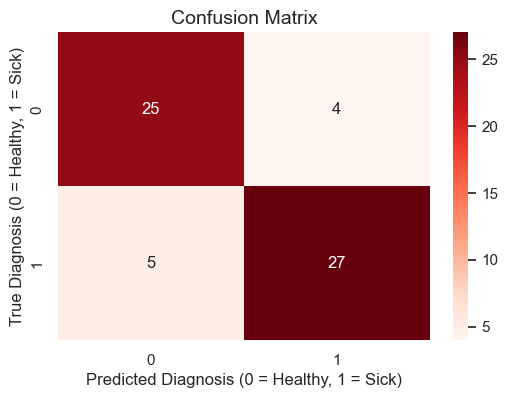

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

cat_cols = ['cp', 'restecg', 'slp', 'caa', 'thall']
df_ml = pd.get_dummies(df_heart, columns=cat_cols, drop_first=True)

X = df_ml.drop('output', axis=1)
y = df_ml['output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("--- Diagnostic Report Card ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Reds', fmt='g')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Diagnosis (0 = Healthy, 1 = Sick)')
plt.ylabel('True Diagnosis (0 = Healthy, 1 = Sick)')
plt.show()